In [83]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,  ConfusionMatrixDisplay,confusion_matrix, accuracy_score

#The MLPClassifier imports goes here





In [84]:
df = pd.read_csv("agaricus-lepiota.data")

# Mushroom Dataset Information

1. **Class Labels**  
   edible = e, poisonous = p

2. **cap-shape**  
   bell = b, conical = c, convex = x, flat = f, knobbed = k, sunken = s

3. **cap-surface**  
   fibrous = f, grooves = g, scaly = y, smooth = s

4. **cap-color**  
   brown = n, buff = b, cinnamon = c, gray = g, green = r, pink = p, purple = u, red = e, white = w, yellow = y

5. **bruises**  
   bruises = t, no = f

6. **odor**  
   almond = a, anise = l, creosote = c, fishy = y, foul = f, musty = m, none = n, pungent = p, spicy = s

7. **gill-attachment**  
   attached = a, descending = d, free = f, notched = n

8. **gill-spacing**  
   close = c, crowded = w, distant = d

9. **gill-size**  
   broad = b, narrow = n

10. **gill-color**  
   black = k, brown = n, buff = b, chocolate = h, gray = g, green = r, orange = o, pink = p, purple = u, red = e, white = w, yellow = y

11. **stalk-shape**  
   enlarging = e, tapering = t

12. **stalk-root**  
   bulbous = b, club = c, cup = u, equal = e, rhizomorphs = z, rooted = r, missing = ?

13. **stalk-surface-above-ring**  
   fibrous = f, scaly = y, silky = k, smooth = s

14. **stalk-surface-below-ring**  
   fibrous = f, scaly = y, silky = k, smooth = s

15. **stalk-color-above-ring**  
   brown = n, buff = b, cinnamon = c, gray = g, orange = o, pink = p, red = e, white = w, yellow = y

16. **stalk-color-below-ring**  
   brown = n, buff = b, cinnamon = c, gray = g, orange = o, pink = p, red = e, white = w, yellow = y

17. **veil-type**  
   partial = p, universal = u

18. **veil-color**  
   brown = n, orange = o, white = w, yellow = y

19. **ring-number**  
   none = n, one = o, two = t

20. **ring-type**  
   cobwebby = c, evanescent = e, flaring = f, large = l, none = n, pendant = p, sheathing = s, zone = z

21. **spore-print-color**  
   black = k, brown = n, buff = b, chocolate = h, green = r, orange = o, purple = u, white = w, yellow = y

22. **population**  
   abundant = a, clustered = c, numerous = n, scattered = s, several = v, solitary = y

23. **habitat**  
   grasses = g, leaves = l, meadows = m, paths = p, urban = u, waste = w, woods = d



In [85]:
df.columns = [
    "edible=e, poisonous=p",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat"
]

output_column=["edible=e, poisonous=p"]

feature_columns=[
   'odor', 'spore-print-color', 'gill-color', 'ring-type',
    'stalk-surface-above-ring', 'stalk-surface-below-ring', 'gill-size',
    'stalk-color-above-ring', 'stalk-color-below-ring', 'bruises',
    'population', 'habitat'
]

In [86]:
df.head()

,"edible=e, poisonous=p",cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


# Preprocessing

In [87]:
empty_row = df.isnull().all(axis=1)

print(df[empty_row])
#Null strings
print(df.isnull().sum())

Empty DataFrame
Columns: [edible=e, poisonous=p, cap-shape, cap-surface, cap-color, bruises, odor, gill-attachment, gill-spacing, gill-size, gill-color, stalk-shape, stalk-root, stalk-surface-above-ring, stalk-surface-below-ring, stalk-color-above-ring, stalk-color-below-ring, veil-type, veil-color, ring-number, ring-type, spore-print-color, population, habitat]
Index: []

[0 rows x 23 columns]
edible=e, poisonous=p       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
sp

In [88]:
#Empty strings
print((df == "").sum())

edible=e, poisonous=p       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [89]:
#Whitespace only
print((df.apply(lambda col: col.astype(str).str.strip() == "")).sum())

edible=e, poisonous=p       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


#### We will treat the "?" as unknown cause if we try to remove rows with ? we will loose 2480 information which is 30.5% of the data , so if we can treat the "?" as unkown that will be better cause the "?" might be a very important feature for decision , if we have all the other features plus we don't know what the stalk-root of this mushroom is then the mushroom is poisonous or edible

In [90]:
# Show only rows AND columns that have "?"
mask = df == "?"
rows_with_q = mask.any(axis=1)
cols_with_q = mask.any(axis=0)

print(df.loc[rows_with_q, cols_with_q])

     stalk-root
3983          ?
4022          ?
4075          ?
4099          ?
4103          ?
...         ...
8118          ?
8119          ?
8120          ?
8121          ?
8122          ?

[2480 rows x 1 columns]


In [91]:
# Checking duplicates
print(f"Dataset shape:     {df.shape}")
print(f"Duplicate rows:    {df.duplicated().sum()}")
print(f"Unique rows:       {df.shape[0] - df.duplicated().sum()}")

Dataset shape:     (8123, 23)
Duplicate rows:    0
Unique rows:       8123


In [92]:
#Data validation
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8123 entries, 0 to 8122
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   edible=e, poisonous=p     8123 non-null   str  
 1   cap-shape                 8123 non-null   str  
 2   cap-surface               8123 non-null   str  
 3   cap-color                 8123 non-null   str  
 4   bruises                   8123 non-null   str  
 5   odor                      8123 non-null   str  
 6   gill-attachment           8123 non-null   str  
 7   gill-spacing              8123 non-null   str  
 8   gill-size                 8123 non-null   str  
 9   gill-color                8123 non-null   str  
 10  stalk-shape               8123 non-null   str  
 11  stalk-root                8123 non-null   str  
 12  stalk-surface-above-ring  8123 non-null   str  
 13  stalk-surface-below-ring  8123 non-null   str  
 14  stalk-color-above-ring    8123 non-null   str  
 15

#### For the sanity check below

1. **Veil-type:**
It has p (partial) as the dominant value across all rows, which means this feature does not provide any useful information for the model to distinguish whether a mushroom is edible or poisonous. Since every observation shares the same value, the model cannot learn any meaningful pattern from this column, so during training we can remove it to decrease training time and model to learn what actually matters

2. **Veil-color:**
 Almost useless — although it has 4 unique values, 97.5% of rows are "w" (white). The remaining 3 values appear in only 200 rows. Barely any variation,so it can also be not considered included when we train the model.

3. **Ring number:**
It has 3 unique values, but 92% of the rows are dominated by 'o' (one ring), which means there is very little variation. This suggests it may not be a particularly useful feature. However, we will keep it for now and revisit its importance during Exploratory Data Analysis (EDA) or when we begin training our model, at that point we will have a clearer picture of whether it contributes meaningfully to predicting edibility.


3. **gill-attachment:**
 Almost useless , although it has 2 unique values, 97.4% of rows are "f" (free). The remaining 1 value appear in only 200 rows. Barely any variation,so it can also be not considered included when we train the model.

3. **gill-spacing:**
It has 2 unique values, 83.8% of rows are "c" (closed). The remaining 1 value appear in only 1312 rows. with this one we at have slight variation so this can be monitored during EDA or model training to see its significance

In [93]:
#Final Sanity check
print(df.describe(include='all'))

       edible=e, poisonous=p cap-shape cap-surface cap-color bruises  odor  \
count                   8123      8123        8123      8123    8123  8123   
unique                     2         6           4        10       2     9   
top                        e         x           y         n       f     n   
freq                    4208      3655        3244      2283    4748  3528   

       gill-attachment gill-spacing gill-size gill-color  ...  \
count             8123         8123      8123       8123  ...   
unique               2            2         2         12  ...   
top                  f            c         b          b  ...   
freq              7913         6811      5612       1728  ...   

       stalk-surface-below-ring stalk-color-above-ring stalk-color-below-ring  \
count                      8123                   8123                   8123   
unique                        4                      9                      9   
top                           s         

# Exploration Data Analysis

##### the dataset is almost perfectly balanced so we don't won't be in a risk of the model being bias

In [94]:
df['edible=e, poisonous=p'].value_counts()

edible=e, poisonous=p
e    4208
p    3915
Name: count, dtype: int64

In [95]:
X = df.drop('edible=e, poisonous=p', axis=1)
y = df['edible=e, poisonous=p']

In [96]:

results =[]

for col in X.columns:
    table = pd.crosstab(X[col], y)
    chi2, p, dof, expected = chi2_contingency(table)
    results.append((col, chi2, f"{p:.10e}"))


results_df = pd.DataFrame(results, columns=['Feature', 'Chi2', 'P-value'])
results_df = results_df.sort_values(by='Chi2', ascending=False)
results_df


,Feature,Chi2,P-value
4,odor,7658.722471,0.0000000000e+00
19,spore-print-color,4604.106487,0.0000000000e+00
8,gill-color,3767.528229,0.0000000000e+00
18,ring-type,2958.099683,0.0000000000e+00
11,stalk-surface-above-ring,2809.218583,0.0000000000e+00
12,stalk-surface-below-ring,2685.324787,0.0000000000e+00
7,gill-size,2365.834165,0.0000000000e+00
13,stalk-color-above-ring,2238.366917,0.0000000000e+00
14,stalk-color-below-ring,2152.860017,0.0000000000e+00
3,bruises,2043.020978,0.0000000000e+00


### Chi-Square (χ²) for Feature Selection

The chi-square test measures how strongly each feature is associated with the
target variable. A **high χ² score** means the feature carries useful
information for prediction, while a **low score (or zero)** means the feature
has no real relationship with the target — it is independent and useless for prediction
.We use it to rank and select the most informative
features before training our model.


##### Tier 1 — strongest features - Highest Chi2 value
tier1 = [
    'odor', 'spore-print-color', 'gill-color', 'ring-type',
    'stalk-surface-above-ring', 'stalk-surface-below-ring', 'gill-size',
    'stalk-color-above-ring', 'stalk-color-below-ring', 'bruises',
    'population', 'habitat'
]

##### Tier 2 — moderate features - Somewhat high Chi2 value
tier2 = [
    'stalk-root', 'gill-spacing', 'cap-shape', 'cap-color',
    'ring-number', 'cap-surface', 'veil-color', 'gill-attachment', 'stalk-shape'
]

##### Always drop
drop = ['veil-type']

##### Use for training
X_train = df[tier1]           # we will test with tier 1 first

X_train_full = df[tier1 + tier2]  # we will test with tier1+tier2 again to see if we get increase in accuracy

In [97]:
# drop veil-type
X = X.drop('veil-type', axis=1)

In [98]:
# Encoding the data for the model
le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col])

y= le.fit_transform(y)


In [99]:
# Data splitting

tier1 = [
    'odor', 'spore-print-color', 'gill-color', 'ring-type',
    'stalk-surface-above-ring', 'stalk-surface-below-ring', 'gill-size',
    'stalk-color-above-ring', 'stalk-color-below-ring', 'bruises',
    'population', 'habitat'
]

tier2 = [
    'stalk-root', 'gill-spacing', 'cap-shape', 'cap-color',
    'ring-number', 'cap-surface', 'veil-color', 'gill-attachment', 'stalk-shape' 
]


# Experiment 1 — Tier 1 features only

# first split — separate test set (20%)
X_train_t1, X_test_t1, y_train_t1, y_test_t1 = train_test_split(
    X[tier1], y, test_size=0.2, random_state=42
)

# second split — separate validation from training (20% of remaining)
X_train_t1, X_val_t1, y_train_t1, y_val_t1 = train_test_split(
    X_train_t1, y_train_t1, test_size=0.2, random_state=42
)


# Experiment 2 — Tier 1 + Tier 2 features

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X[tier1 + tier2], y, test_size=0.2, random_state=42
)

X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

### Experiment 1 - Tier 1 features

In [100]:
estimators = [1,2,3,5,6,7,8,9,10, 50, 100, 200,300, 500, 1000]
val_scores_t1 = []

for n in estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_t1, y_train_t1)
    val_score = rf.score(X_val_t1, y_val_t1)
    val_scores_t1.append(val_score)
    print(f"Tier 1 - Estimators: {n}, Validation Accuracy: {val_score:.4f}")

Tier 1 - Estimators: 1, Validation Accuracy: 1.0000
Tier 1 - Estimators: 2, Validation Accuracy: 1.0000
Tier 1 - Estimators: 3, Validation Accuracy: 1.0000
Tier 1 - Estimators: 5, Validation Accuracy: 1.0000
Tier 1 - Estimators: 6, Validation Accuracy: 1.0000
Tier 1 - Estimators: 7, Validation Accuracy: 1.0000
Tier 1 - Estimators: 8, Validation Accuracy: 1.0000
Tier 1 - Estimators: 9, Validation Accuracy: 1.0000
Tier 1 - Estimators: 10, Validation Accuracy: 1.0000
Tier 1 - Estimators: 50, Validation Accuracy: 1.0000
Tier 1 - Estimators: 100, Validation Accuracy: 1.0000
Tier 1 - Estimators: 200, Validation Accuracy: 1.0000
Tier 1 - Estimators: 300, Validation Accuracy: 1.0000
Tier 1 - Estimators: 500, Validation Accuracy: 1.0000
Tier 1 - Estimators: 1000, Validation Accuracy: 1.0000


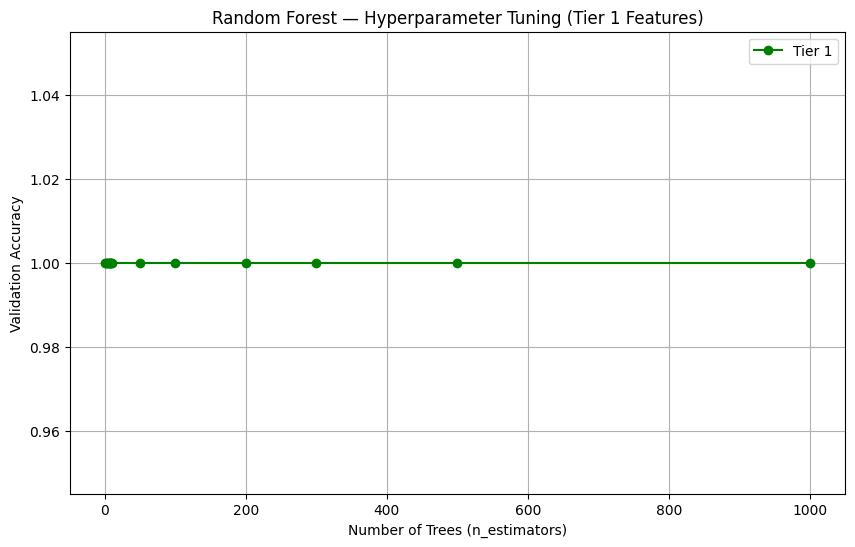

In [101]:
plt.figure(figsize=(10, 6))
plt.plot(estimators, val_scores_t1, marker='o', color='green', label='Tier 1')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation Accuracy')
plt.title('Random Forest — Hyperparameter Tuning (Tier 1 Features)')
plt.legend()
plt.grid(True)
plt.show()

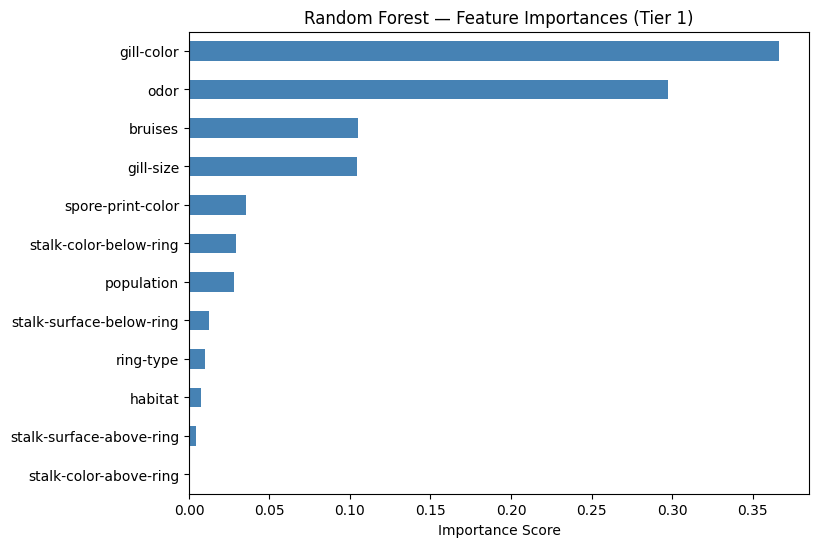

In [102]:
# feature importance plot

# pick best model
best_n = estimators[val_scores_t1.index(max(val_scores_t1))]
rf_best = RandomForestClassifier(n_estimators=best_n, random_state=42)
rf_best.fit(X_train_t1, y_train_t1)

importances = pd.Series(rf_best.feature_importances_, index=X_train_t1.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Random Forest — Feature Importances (Tier 1)')
plt.xlabel('Importance Score')
plt.show()

=== Final Test Results — Random Forest (Tier 1) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       853
           1       1.00      1.00      1.00       772

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



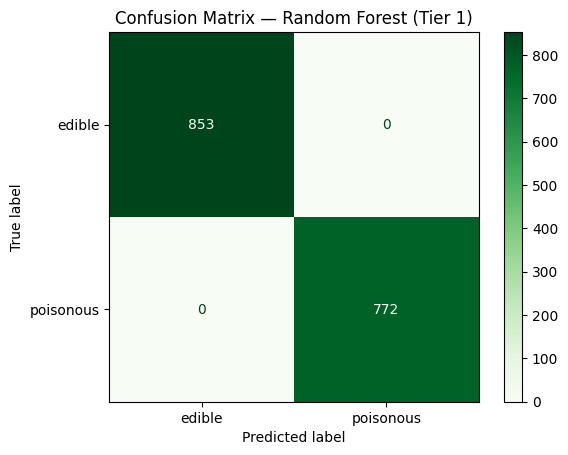

In [103]:
y_test_pred = rf_best.predict(X_test_t1)

print("=== Final Test Results — Random Forest (Tier 1) ===")
print(classification_report(y_test_t1, y_test_pred))

cm = confusion_matrix(y_test_t1, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['edible', 'poisonous'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix — Random Forest (Tier 1)')
plt.show()

#### The Random Forest achieved 100% validation accuracy across all values of n_estimators, confirming that the Tier 1 features selected via chi-square analysis are sufficient for perfect classification. This suggests the dataset is linearly separable in the feature space.

### Experiment 2 - Tier 2 features

In [104]:
estimators_full = [1,2,3,5,6,7,8,9,10, 50, 100, 200,300, 500, 1000]
val_scores_full = []

for n in estimators_full:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_full, y_train_full)
    score = accuracy_score(y_val_full, rf.predict(X_val_full))
    val_scores_full.append(score)
    print(f"n_estimators={n}: val accuracy = {score:.4f}")

n_estimators=1: val accuracy = 1.0000
n_estimators=2: val accuracy = 1.0000
n_estimators=3: val accuracy = 1.0000
n_estimators=5: val accuracy = 1.0000
n_estimators=6: val accuracy = 1.0000
n_estimators=7: val accuracy = 1.0000
n_estimators=8: val accuracy = 1.0000
n_estimators=9: val accuracy = 1.0000
n_estimators=10: val accuracy = 1.0000
n_estimators=50: val accuracy = 1.0000
n_estimators=100: val accuracy = 1.0000
n_estimators=200: val accuracy = 1.0000
n_estimators=300: val accuracy = 1.0000
n_estimators=500: val accuracy = 1.0000
n_estimators=1000: val accuracy = 1.0000


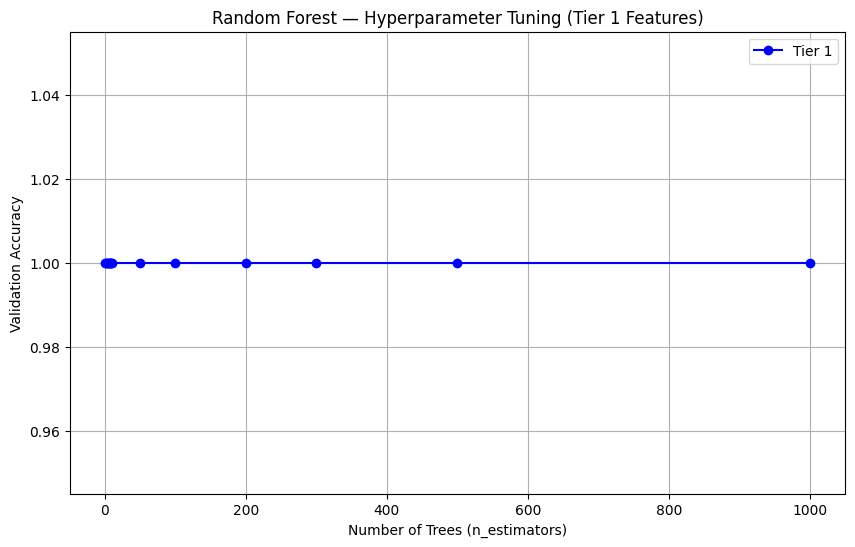

In [105]:
plt.figure(figsize=(10, 6))
plt.plot(estimators_full, val_scores_full, marker='o', color='blue', label='Tier 1')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation Accuracy')
plt.title('Random Forest — Hyperparameter Tuning (Tier 1 Features)')
plt.legend()
plt.grid(True)
plt.show()

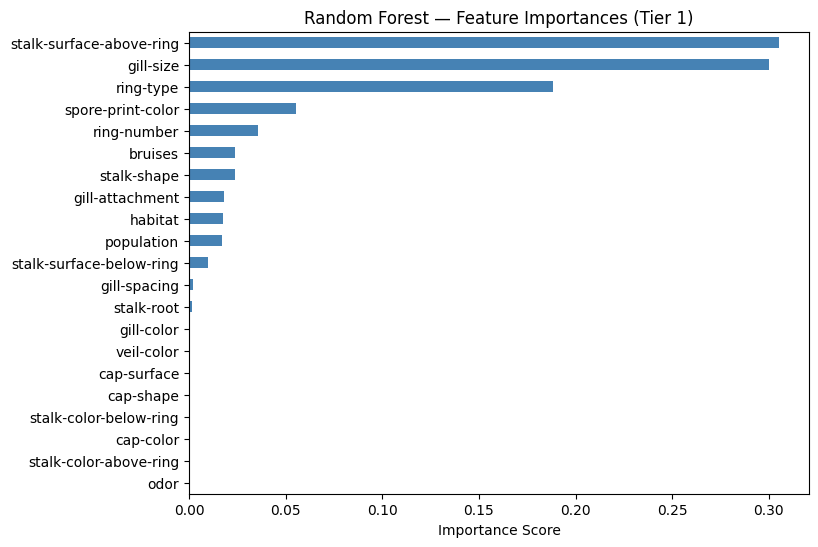

In [106]:
# feature importance plot

# pick best model
best_n = estimators_full[val_scores_full.index(max(val_scores_full))]
rf_best = RandomForestClassifier(n_estimators=best_n, random_state=42)
rf_best.fit(X_train_full, y_train_full)

importances = pd.Series(rf_best.feature_importances_, index=X_train_full.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Random Forest — Feature Importances (Tier 1)')
plt.xlabel('Importance Score')
plt.show()

=== Final Test Results — Random Forest (Tier 1) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       853
           1       1.00      1.00      1.00       772

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



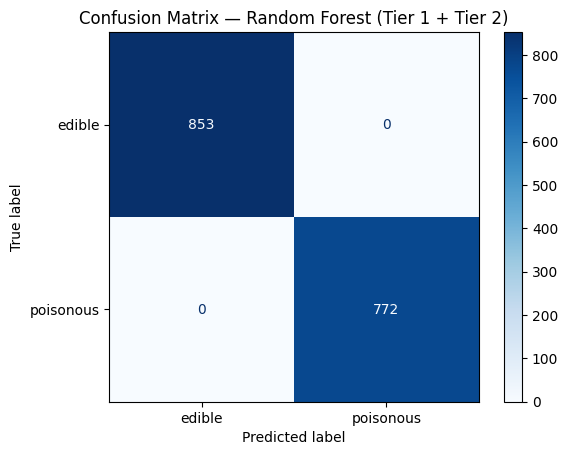

In [107]:
y_test_pred = rf_best.predict(X_test_full)


print("=== Final Test Results — Random Forest (Tier 1) ===")
print(classification_report(y_test_full, y_test_pred))


cm = confusion_matrix(y_test_full, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['edible', 'poisonous'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest (Tier 1 + Tier 2)')
plt.show()

### Testing the effect of the depth of the tree

In [108]:
depths = [1, 2, 3, 4, 5, 6,7,8,9,10, 15, 20, None]

# Tier 1
val_scores_t1 = []
for d in depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train_t1, y_train_t1)
    score = accuracy_score(y_val_t1, rf.predict(X_val_t1))
    val_scores_t1.append(score)
    print(f"Tier 1 - max_depth={d}: val accuracy = {score:.4f}")

print()

# Tier 1 + Tier 2
val_scores_full = []
for d in depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train_full, y_train_full)
    score = accuracy_score(y_val_full, rf.predict(X_val_full))
    val_scores_full.append(score)
    print(f"Tier 1+2 - max_depth={d}: val accuracy = {score:.4f}")

Tier 1 - max_depth=1: val accuracy = 0.8762
Tier 1 - max_depth=2: val accuracy = 0.9669
Tier 1 - max_depth=3: val accuracy = 0.9908
Tier 1 - max_depth=4: val accuracy = 0.9923
Tier 1 - max_depth=5: val accuracy = 0.9923
Tier 1 - max_depth=6: val accuracy = 0.9931
Tier 1 - max_depth=7: val accuracy = 0.9962
Tier 1 - max_depth=8: val accuracy = 1.0000
Tier 1 - max_depth=9: val accuracy = 1.0000
Tier 1 - max_depth=10: val accuracy = 1.0000
Tier 1 - max_depth=15: val accuracy = 1.0000
Tier 1 - max_depth=20: val accuracy = 1.0000
Tier 1 - max_depth=None: val accuracy = 1.0000

Tier 1+2 - max_depth=1: val accuracy = 0.8915
Tier 1+2 - max_depth=2: val accuracy = 0.9300
Tier 1+2 - max_depth=3: val accuracy = 0.9792
Tier 1+2 - max_depth=4: val accuracy = 0.9923
Tier 1+2 - max_depth=5: val accuracy = 0.9923
Tier 1+2 - max_depth=6: val accuracy = 0.9931
Tier 1+2 - max_depth=7: val accuracy = 0.9954
Tier 1+2 - max_depth=8: val accuracy = 1.0000
Tier 1+2 - max_depth=9: val accuracy = 1.0000
Tier 1+

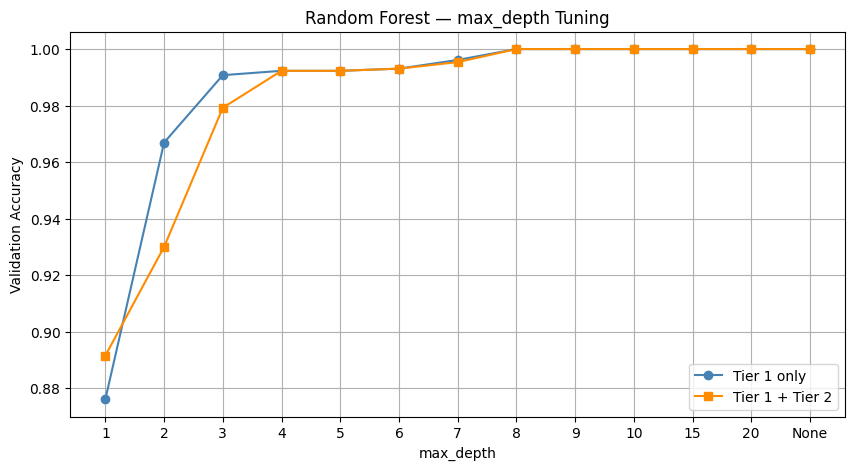

In [109]:
# ── Accuracy vs Depth plot ───────────────────────────
depth_labels = [str(d) for d in depths]

plt.figure(figsize=(10, 5))
plt.plot(depth_labels, val_scores_t1,   marker='o', label='Tier 1 only',     color='steelblue')
plt.plot(depth_labels, val_scores_full, marker='s', label='Tier 1 + Tier 2', color='darkorange')
plt.xlabel('max_depth')
plt.ylabel('Validation Accuracy')
plt.title('Random Forest — max_depth Tuning')
plt.legend()
plt.grid(True)
plt.show()

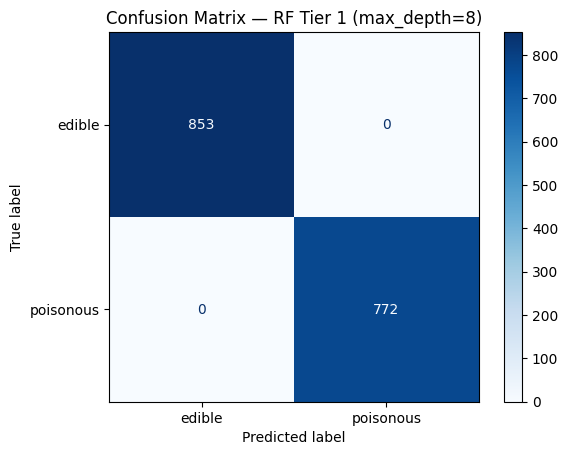

In [110]:
# ── Best model — Tier 1 ─────────────────────────────
best_depth_t1 = depths[val_scores_t1.index(max(val_scores_t1))]
rf_best_t1 = RandomForestClassifier(n_estimators=100, max_depth=best_depth_t1, random_state=42)
rf_best_t1.fit(X_train_t1, y_train_t1)

cm_t1 = confusion_matrix(y_test_t1, rf_best_t1.predict(X_test_t1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_t1, display_labels=['edible', 'poisonous'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — RF Tier 1 (max_depth={best_depth_t1})')
plt.show()

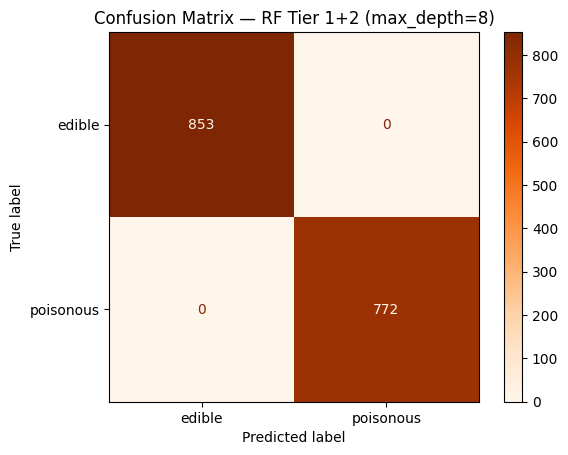

In [111]:
# ── Best model — Tier 1 + Tier 2 ────────────────────
best_depth_full = depths[val_scores_full.index(max(val_scores_full))]
rf_best_full = RandomForestClassifier(n_estimators=100, max_depth=best_depth_full, random_state=42)
rf_best_full.fit(X_train_full, y_train_full)

cm_full = confusion_matrix(y_test_full, rf_best_full.predict(X_test_full))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_full, display_labels=['edible', 'poisonous'])
disp.plot(cmap='Oranges')
plt.title(f'Confusion Matrix — RF Tier 1+2 (max_depth={best_depth_full})')
plt.show()

# DNN Model

## Encoding Data with meumerical values: 

In [112]:
from sklearn.preprocessing import LabelEncoder

vocabulary_sizes={}
numerical_df=pd.DataFrame()

for col in df.columns:
    
    encoder = LabelEncoder()
    numerical_df[col]=encoder.fit_transform(df[col])
    vocabulary_sizes[col]= len(encoder.classes_)

numerical_df

,"edible=e, poisonous=p",cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
1,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
2,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
3,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
4,0,5,3,9,1,0,1,0,0,5,...,2,7,7,0,2,1,4,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8118,0,3,2,4,0,5,0,0,0,11,...,2,5,5,0,1,1,4,0,1,2
8119,0,5,2,4,0,5,0,0,0,11,...,2,5,5,0,0,1,4,0,4,2
8120,0,2,2,4,0,5,0,0,0,5,...,2,5,5,0,1,1,4,0,1,2
8121,1,3,3,4,0,8,1,0,1,0,...,1,7,7,0,2,1,0,7,4,2


## Data Split

60% training, 20% testing, 20% validation

In [113]:
from sklearn.model_selection import train_test_split

X= numerical_df[feature_columns]
y= numerical_df[output_column]

X_train,X_tmp, y_train, y_tmp= train_test_split(X,y, test_size=0.4,random_state=42)
X_val,X_test, y_val, y_test=train_test_split(X_tmp,y_tmp, test_size=0.5,random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

(4873, 12) (1625, 12) (1625, 12)


## Setting Up embeddings 

In [114]:
from tensorflow.keras.layers import (Input,Embedding)

inputs=[]
embeddings=[]

for col in feature_columns:

    input_layer= Input(shape=(1,),name=col)
    vocabulary_size= vocabulary_sizes[col]
    embedding_size=min(10,(vocabulary_size//2))

    embedding= Embedding(input_dim=vocabulary_size+1,output_dim=embedding_size,name=f"{col}_embedding")(input_layer)

    inputs.append(input_layer)
    embeddings.append(embedding)

## Building The model

In [115]:
from tensorflow.keras.layers import (Concatenate,Dense,Dropout)


x= Concatenate()(embeddings)

x= Dense(2,activation='relu')(x)
x= Dropout(0.3)(x)

x= Dense(1,activation='relu')(x)
x= Dropout(0.3)(x)

output= Dense(1,activation= 'sigmoid')(x)

## Model

In [116]:
from tensorflow.keras.models import Model

model= Model(inputs=inputs, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ odor (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spore-print-color   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gill-color          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ring-type           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stalk-surface-abov… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stalk-surface-belo… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gill-size           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stalk-color-above-… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stalk-color-below-… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bruises             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ population          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ habitat             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ odor_embedding      │ (None, 1, 4)      │         40 │ odor[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spore-print-color_… │ (None, 1, 4)      │         40 │ spore-print-colo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gill-color_embeddi… │ (None, 1, 6)      │         78 │ gill-color[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ring-type_embedding │ (None, 1, 2)      │         12 │ ring-type[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stalk-surface-abov… │ (None, 1, 2)      │         10 │ stalk-surface-ab… │
│ (Embedding)         │                   │            │                 

 Total params: 400 (1.56 KB)

 Trainable params: 400 (1.56 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [117]:
def listify(data):
   

    X_list =[data.iloc[:,i:i+1]for i in range(data.shape[1])]
    return X_list

In [118]:
X_train_list = listify(X_train)
X_val_list=listify(X_val)


history = model.fit(X_train_list,y_train,validation_data=(X_val_list, y_val),epochs=10,batch_size=30)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5182 - loss: 0.6689 - val_accuracy: 0.8671 - val_loss: 0.5869
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7080 - loss: 0.5610 - val_accuracy: 0.9662 - val_loss: 0.4411
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7133 - loss: 0.5272 - val_accuracy: 0.9846 - val_loss: 0.3882
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7308 - loss: 0.5060 - val_accuracy: 0.9846 - val_loss: 0.3507
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7285 - loss: 0.4989 - val_accuracy: 0.9846 - val_loss: 0.3187
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7244 - loss: 0.4957 - val_accuracy: 0.9858 - val_loss: 0.2989
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7287 - loss: 0.4892 - val_accuracy: 0.9969 - val_loss: 0.2776
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7273 - loss: 0.4852 - val_accuracy: 0.

### Loss curve

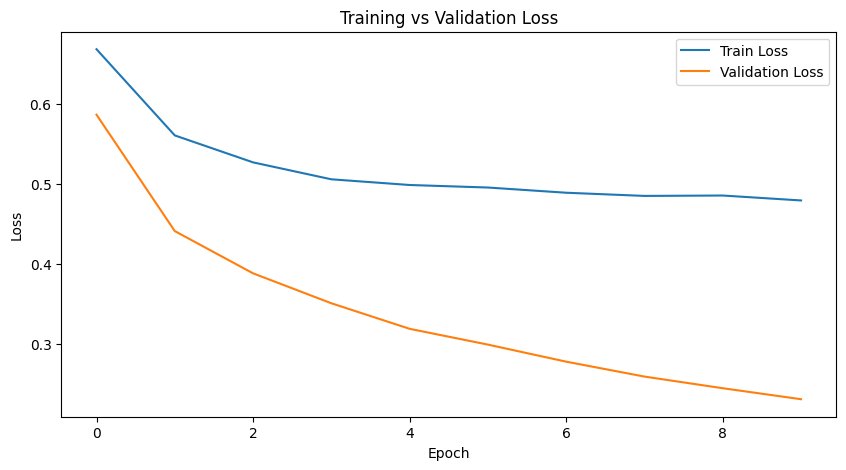

In [119]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

## Accuracy Curve

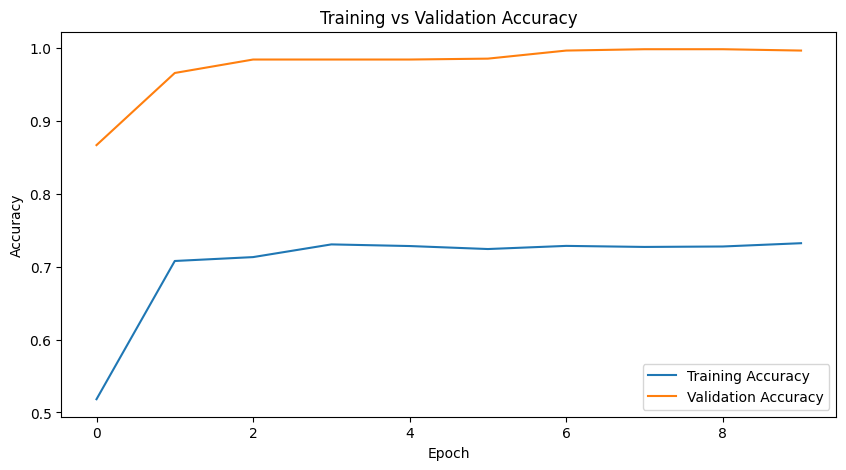

In [120]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()

## Confusion matrix: Training

153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
(4873, 1, 1)
(1625, 1)


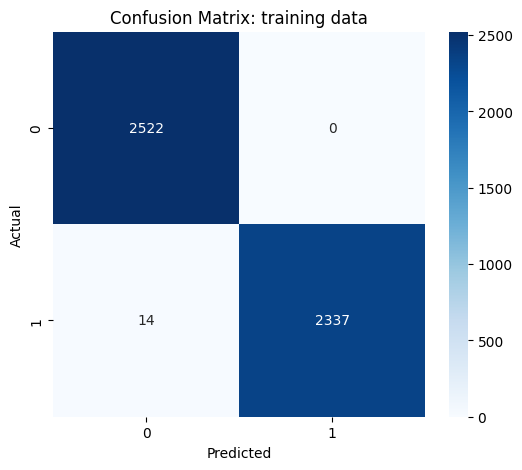

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2522
           1       1.00      0.99      1.00      2351

    accuracy                           1.00      4873
   macro avg       1.00      1.00      1.00      4873
weighted avg       1.00      1.00      1.00      4873



In [121]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
y_probs = model.predict(X_train_list)
y_pred = (y_probs > 0.5).astype(int)

print(y_pred.shape)
print(y_val.shape)

cm = confusion_matrix(y_train, y_pred.squeeze())
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: training data')

plt.show()
print(classification_report(y_train, y_pred.squeeze()))

## Confusion matrix : Validation

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
(1625, 1, 1)
(1625, 1)


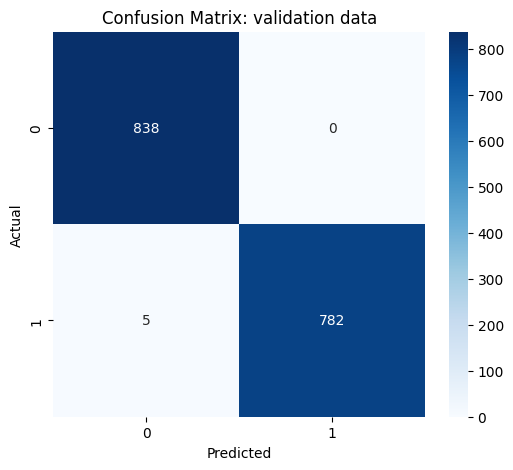

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       838
           1       1.00      0.99      1.00       787

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [122]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
y_probs = model.predict(X_val_list)
y_pred = (y_probs > 0.5).astype(int)

print(y_pred.shape)
print(y_val.shape)

cm = confusion_matrix(y_val, y_pred.squeeze())
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: validation data')

plt.show()
print(classification_report(y_val, y_pred.squeeze()))

## Confusion matrix : testing

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


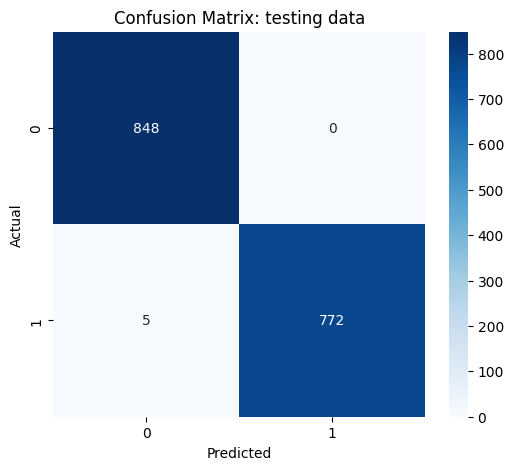

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       848
           1       1.00      0.99      1.00       777

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [123]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

X_test_list= listify(X_test)

pred_probs = model.predict(X_test_list)
pred_classes = (pred_probs>0.5).astype(int)

cm = confusion_matrix(y_test, pred_classes.squeeze())


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: testing data')

plt.show()
print(classification_report(y_test, pred_classes.squeeze()))